In [8]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt


In [9]:
# data folder
notebook_dir = pathlib.Path.cwd()
parent = notebook_dir.parent
data_folder = parent / "data" 

# read file
data = pd.read_csv(data_folder / "Coupling Efficiency Stats.csv")
print(data.head())


            Couplers Reference dBm  stable dBm  max dBm  \
0  L_5-6 (reference)             -       -1.90    -1.85   
1            L_18-19         -3.47       -4.33    -3.18   
2            L_27-28          -5.5       -5.17    -5.14   
3  R_1-2 (reference)             -       -3.04    -2.94   
4            R_12-13          -3.7       -2.18    -1.81   

                                               Notes  
0                                   Reference config  
1  When adjusting to couple both as reference it ...  
2  Still needed to adjust rotation around x (diff...  
3                                                NaN  
4          Was -20, changed connector and got better  


TOTAL:
Total average stable dBm: -3.4499999999999997
Total variance stable dBm: 1.3776666666666666
LEFT:
Left average stable dBm: -3.8000000000000003
Left variance stable dBm: 2.8839
RIGHT:
Right average stable dBm: -3.1875
Right variance stable dBm: 0.6183583333333332


/var/folders/81/cnj48f8x1j93q4hjhfns86zh0000gn/T/ipykernel_75229/3177652851.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stable_dbm_left, stable_dbm_right, stable_dbm],


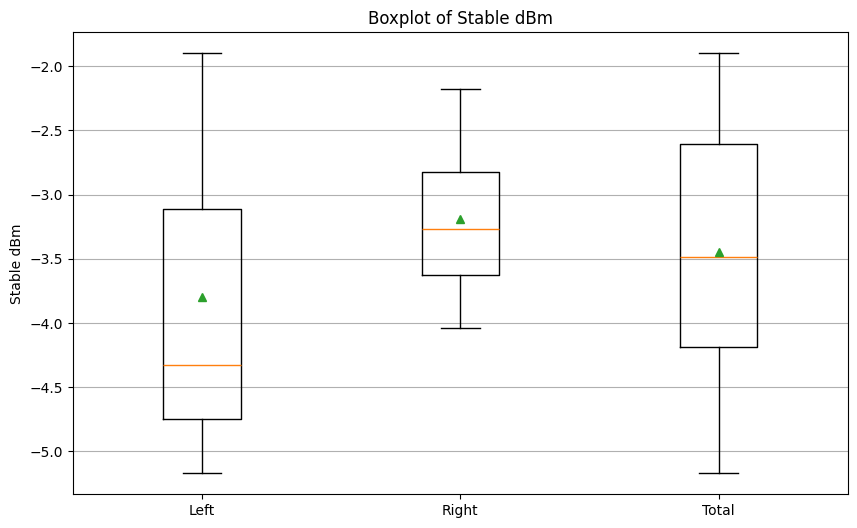

In [15]:
# boxplot left, righ and total coupling efficiency

stable_dbm = data['stable dBm']
stable_dbm_left = data['stable dBm'][data['Couplers'].str.contains('L')]
stable_dbm_right = data['stable dBm'][data['Couplers'].str.contains('R')]

print('TOTAL:')
print('Total average stable dBm:',stable_dbm.mean())
print('Total variance stable dBm:', stable_dbm.var())

print('LEFT:')
print('Left average stable dBm:', stable_dbm_left.mean())
print('Left variance stable dBm:', stable_dbm_left.var())

print('RIGHT:')
print('Right average stable dBm:', stable_dbm_right.mean())
print('Right variance stable dBm:', stable_dbm_right.var())

plt.figure(figsize=(10, 6))
plt.boxplot([stable_dbm_left, stable_dbm_right, stable_dbm],
            labels=['Left', 'Right', 'Total'],
            showmeans=True)
plt.title('Boxplot of Stable dBm')
plt.ylabel('Stable dBm')
plt.grid(axis='y')
plt.show()